# timesfm experiment v3 — xreg known-future covariates + corrected calibration

v1 raw zero-shot achieved `1672.25` wmae; v2's calibrated seasonal/raw/residual blend achieved `1620.54`. v3 adds timesfm 2.5 xreg with leakage-safe calendar, holiday, store and external covariates. it reuses v2 predictions from w&b, compares both official xreg modes on historical calibration, and fixes v2's calibration mismatch by clipping every candidate blend **inside** the weight-search objective. no timesfm parameter is trained or fine-tuned.

In [1]:
# xreg is part of the official timesfm package and uses scikit-learn/jax helpers.
%pip install -q -U "timesfm[torch,xreg]==2.0.2" wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 741.0 kB/s eta 0:00:00


In [2]:
import os

# keep jax/xreg on cpu so it does not reserve the t4 memory used by timesfm torch.
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import hashlib
import json
import platform
import time
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import wandb
import timesfm

warnings.filterwarnings("ignore")
torch.set_float32_matmul_precision("high")
print(
    {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "timesfm": getattr(timesfm, "__version__", "unknown"),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    }
)

{'python': '3.12.13', 'torch': '2.11.0+cu128', 'timesfm': 'unknown', 'gpu': 'Tesla T4'}


In [3]:
CONFIG = {
    "data_dir": "/content/drive/MyDrive/walmart_competition_data",
    "output_dir": "/content/artifacts/timesfm_xreg_v3",
    "model_id": "google/timesfm-2.5-200m-pytorch",
    "v2_artifact": "timesfm-v2-zero-shot-residual-calibration:latest",
    "validation_weeks": 39,
    "calibration_weeks": 20,
    "seasonal_period": 52,
    "xreg_modes": ["xreg + timesfm", "timesfm + xreg"],
    "weight_step": 0.05,
    "holiday_weight": 5.0,
    "clip_min": 0.0,
    "clip_max": 300000.0,
    "wandb_entity": "kende23-n-a",
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "wandb_run_name": "timesfm_v3_xreg_covariates_corrected_blend",
    "seed": 42,
}
DATA_DIR, OUTPUT_DIR = Path(CONFIG["data_dir"]), Path(CONFIG["output_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(CONFIG["seed"])
print(CONFIG)

{'data_dir': '/content/drive/MyDrive/walmart_competition_data', 'output_dir': '/content/artifacts/timesfm_xreg_v3', 'model_id': 'google/timesfm-2.5-200m-pytorch', 'v2_artifact': 'timesfm-v2-zero-shot-residual-calibration:latest', 'validation_weeks': 39, 'calibration_weeks': 20, 'seasonal_period': 52, 'xreg_modes': ['xreg + timesfm', 'timesfm + xreg'], 'weight_step': 0.05, 'holiday_weight': 5.0, 'clip_min': 0.0, 'clip_max': 300000.0, 'wandb_entity': 'kende23-n-a', 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting', 'wandb_run_name': 'timesfm_v3_xreg_covariates_corrected_blend', 'seed': 42}


In [4]:
try:
    from google.colab import drive, userdata

    drive.mount("/content/drive")
    wandb_key = userdata.get("WANDB_API_KEY")
except Exception:
    wandb_key = None
wandb.login(key=wandb_key) if wandb_key else wandb.login()

Mounted at /content/drive


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## load raw data and v2 evaluation artifact

In [5]:
def locate_csv(root, name):
    for path in [root / name, root / f"{name}.zip"]:
        if path.exists():
            return path
    raise FileNotFoundError(f"Missing {name} or {name}.zip in {root}")


def wmae(y, p, h, holiday_weight=5.0):
    y, p = np.asarray(y, float), np.asarray(p, float)
    weights = np.where(np.asarray(h, bool), holiday_weight, 1.0)
    return float(np.sum(weights * np.abs(y - p)) / np.sum(weights))


train = (
    pd.read_csv(locate_csv(DATA_DIR, "train.csv"), parse_dates=["Date"])
    .sort_values(["Store", "Dept", "Date"])
    .reset_index(drop=True)
)
features = (
    pd.read_csv(locate_csv(DATA_DIR, "features.csv"), parse_dates=["Date"])
    .sort_values(["Store", "Date"])
    .reset_index(drop=True)
)
stores = pd.read_csv(locate_csv(DATA_DIR, "stores.csv"))
train["Weekly_Sales"] = (
    pd.to_numeric(train.Weekly_Sales, errors="coerce").fillna(0).astype("float32")
)
train["IsHoliday"] = train.IsHoliday.astype(bool)
all_dates = pd.DatetimeIndex(sorted(train.Date.unique()))
final_start = len(all_dates) - CONFIG["validation_weeks"]
calibration_start = final_start - CONFIG["calibration_weeks"]
calibration_dates = all_dates[calibration_start:final_start]
validation_dates = all_dates[final_start:]
evaluation_keys = sorted(
    map(
        tuple,
        train[train.Date.isin(validation_dates)][["Store", "Dept"]]
        .drop_duplicates()
        .to_numpy(),
    )
)
key_to_index = {k: i for i, k in enumerate(evaluation_keys)}
lookup = train.set_index(["Store", "Dept", "Date"]).Weekly_Sales
sales = np.zeros((len(evaluation_keys), len(all_dates)), np.float32)
for i, (store, dept) in enumerate(evaluation_keys):
    idx = pd.MultiIndex.from_product(
        [[store], [dept], all_dates], names=["Store", "Dept", "Date"]
    )
    sales[i] = lookup.reindex(idx).fillna(0).to_numpy(np.float32)
print(
    {
        "rows": len(train),
        "series": len(evaluation_keys),
        "calibration": f"{calibration_dates.min().date()} -> {calibration_dates.max().date()}",
        "validation": f"{validation_dates.min().date()} -> {validation_dates.max().date()}",
    }
)

{'rows': 421570, 'series': 3204, 'calibration': '2011-09-16 -> 2012-01-27', 'validation': '2012-02-03 -> 2012-10-26'}


In [6]:
# reuse v2 raw/residual/seasonal forecasts instead of spending another ~39 gpu minutes.
api = wandb.Api()
artifact = api.artifact(
    f"{CONFIG['wandb_entity']}/{CONFIG['wandb_project']}/{CONFIG['v2_artifact']}"
)
v2_dir = Path(artifact.download(root=str(OUTPUT_DIR / "v2_artifact")))
calibration_df = pd.read_csv(
    v2_dir / "calibration_predictions.csv", parse_dates=["Date"]
)
validation_df = pd.read_csv(v2_dir / "validation_predictions.csv", parse_dates=["Date"])
required = {
    "Store",
    "Dept",
    "Date",
    "IsHoliday",
    "Weekly_Sales",
    "SeasonalNaive52",
    "TimesFM_Raw",
    "TimesFM_Residual",
}
assert required.issubset(calibration_df.columns) and required.issubset(
    validation_df.columns
)
print(
    {
        "v2_artifact": artifact.name,
        "calibration_rows": len(calibration_df),
        "validation_rows": len(validation_df),
    }
)

wandb:   6 of 6 files downloaded.  


{'v2_artifact': 'timesfm-v2-zero-shot-residual-calibration:latest', 'calibration_rows': 59317, 'validation_rows': 115588}


## leakage-safe xreg covariates

every dynamic covariate spans context and forecast horizon, as required by timesfm. future values come only from the supplied `features.csv`/calendar. missing markdown is represented by zero plus a missing indicator; other numeric variables use forward fill and context-only medians—never backward fill from the forecast period.

In [7]:
store_meta = stores.set_index("Store")
feature_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
markdown_cols = [f"MarkDown{i}" for i in range(1, 6)]


def event_name(date, is_holiday):
    if not is_holiday:
        return "none"
    return {2: "super_bowl", 9: "labor_day", 11: "thanksgiving", 12: "christmas"}.get(
        date.month, "other_holiday"
    )


def build_xreg(origin, horizon):
    dates = all_dates[: origin + horizon]
    context_dates = all_dates[:origin]
    base = pd.MultiIndex.from_product(
        [sorted(train.Store.unique()), dates], names=["Store", "Date"]
    ).to_frame(index=False)
    f = base.merge(
        features, on=["Store", "Date"], how="left", suffixes=("", "_feature")
    ).sort_values(["Store", "Date"])
    holiday_source = (
        f["IsHoliday_feature"] if "IsHoliday_feature" in f else f["IsHoliday"]
    )
    f["holiday"] = holiday_source.fillna(False).astype(bool)
    context_mask = f.Date.isin(context_dates)
    context_medians = {
        c: pd.to_numeric(f.loc[context_mask, c], errors="coerce").median()
        for c in feature_cols
    }
    for c in feature_cols:
        values = pd.to_numeric(f[c], errors="coerce")
        f[c + "_missing"] = values.isna().astype(float)
        f[c] = values.groupby(f.Store).ffill().fillna(context_medians[c]).fillna(0.0)
    md = f[markdown_cols].apply(pd.to_numeric, errors="coerce")
    f["markdown_missing_count"] = md.isna().sum(axis=1).astype(float)
    f["markdown_log_total"] = np.log1p(md.fillna(0).clip(lower=0).sum(axis=1))
    iso = f.Date.dt.isocalendar()
    f["week_sin"] = np.sin(2 * np.pi * iso.week.astype(float) / 52.0)
    f["week_cos"] = np.cos(2 * np.pi * iso.week.astype(float) / 52.0)
    f["month_sin"] = np.sin(2 * np.pi * f.Date.dt.month / 12.0)
    f["month_cos"] = np.cos(2 * np.pi * f.Date.dt.month / 12.0)
    f["event"] = [event_name(d, h) for d, h in zip(f.Date, f.holiday)]
    f["week_of_year"] = iso.week.astype(str)
    f["holiday_cat"] = f.holiday.astype(int).astype(str)
    indexed = {
        (int(store), date): row
        for (store, date), row in f.set_index(["Store", "Date"]).iterrows()
    }
    numeric_names = (
        feature_cols
        + [c + "_missing" for c in feature_cols]
        + [
            "markdown_log_total",
            "markdown_missing_count",
            "week_sin",
            "week_cos",
            "month_sin",
            "month_cos",
        ]
    )
    dynamic_num = {name: [] for name in numeric_names}
    dynamic_cat = {name: [] for name in ["holiday_cat", "event", "week_of_year"]}
    for store, dept in evaluation_keys:
        rows = [indexed[(int(store), d)] for d in dates]
        for name in numeric_names:
            dynamic_num[name].append(
                np.asarray([r[name] for r in rows], dtype=np.float32)
            )
        for name in dynamic_cat:
            dynamic_cat[name].append([str(r[name]) for r in rows])
    static_cat = {
        "Store": [str(s) for s, d in evaluation_keys],
        "Dept": [str(d) for s, d in evaluation_keys],
        "Type": [str(store_meta.loc[s, "Type"]) for s, d in evaluation_keys],
    }
    static_num = {
        "Size": [float(store_meta.loc[s, "Size"]) for s, d in evaluation_keys]
    }
    for values in dynamic_num.values():
        assert all(len(x) == origin + horizon and np.isfinite(x).all() for x in values)
    return dynamic_num, dynamic_cat, static_num, static_cat


cal_cov = build_xreg(calibration_start, CONFIG["calibration_weeks"])
final_cov = build_xreg(final_start, CONFIG["validation_weeks"])
print(
    {
        "dynamic_numerical": list(cal_cov[0]),
        "dynamic_categorical": list(cal_cov[1]),
        "static_numerical": list(cal_cov[2]),
        "static_categorical": list(cal_cov[3]),
    }
)

{'dynamic_numerical': ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Temperature_missing', 'Fuel_Price_missing', 'CPI_missing', 'Unemployment_missing', 'markdown_log_total', 'markdown_missing_count', 'week_sin', 'week_cos', 'month_sin', 'month_cos'], 'dynamic_categorical': ['holiday_cat', 'event', 'week_of_year'], 'static_numerical': ['Size'], 'static_categorical': ['Store', 'Dept', 'Type']}


## load timesfm 2.5 and compare both xreg modes on calibration

In [13]:
if not torch.cuda.is_available():
    print("WARNING: select a T4 GPU in Colab.")
load_started = time.time()
model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(CONFIG["model_id"])
model.compile(
    timesfm.ForecastConfig(
        max_context=256,
        max_horizon=64,
        normalize_inputs=True,
        per_core_batch_size=32,
        use_continuous_quantile_head=False,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
        return_backcast=True,
    )
)
load_seconds = time.time() - load_started
print(
    {
        "load_seconds": load_seconds,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
    }
)

{'load_seconds': 3.112541913986206, 'device': 'cuda'}


In [10]:
try:
    from google.colab import userdata

    wandb_key = userdata.get("WANDB_API_KEY")
except Exception:
    wandb_key = None
wandb.login(key=wandb_key) if wandb_key else wandb.login()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [16]:
def xreg_forecast(contexts, horizon, covariates, mode):
    started = time.time()
    dn, dc, sn, sc = covariates
    combined, pure_xreg = model.forecast_with_covariates(
        inputs=[x.astype(np.float32) for x in contexts],
        dynamic_numerical_covariates=dn,
        dynamic_categorical_covariates=dc,
        static_numerical_covariates=sn,
        static_categorical_covariates=sc,
        xreg_mode=mode,
    )
    # convert to numpy immediately to handle shape/clipping
    combined = np.asarray(combined, float)
    pure_xreg = np.asarray(pure_xreg, float)
    # select index 0 of the last dimension for point forecast if pure_xreg has 3 dimensions (batch, horizon, quantiles)
    if len(pure_xreg.shape) == 3:
        pure_xreg = pure_xreg[..., 0]
    combined = np.clip(
        np.nan_to_num(combined, nan=0, posinf=CONFIG["clip_max"], neginf=0),
        CONFIG["clip_min"],
        CONFIG["clip_max"],
    )
    pure_xreg = np.clip(
        np.nan_to_num(pure_xreg, nan=0, posinf=CONFIG["clip_max"], neginf=0),
        CONFIG["clip_min"],
        CONFIG["clip_max"],
    )
    print(
        {
            "mode": mode,
            "shape": combined.shape,
            "pure_shape": pure_xreg.shape,
            "minutes": (time.time() - started) / 60,
            "finite": bool(np.isfinite(combined).all()),
        }
    )
    return combined, pure_xreg, (time.time() - started) / 60


def matrix_to_rows(matrix, frame, dates):
    hmap = {d: i for i, d in enumerate(dates)}
    return np.asarray(
        [
            matrix[key_to_index[(int(r.Store), int(r.Dept))], hmap[r.Date]]
            for r in frame.itertuples(index=False)
        ],
        float,
    )


cal_mode_results = {}
runtime_minutes = 0.0
for mode in CONFIG["xreg_modes"]:
    combined, pure, mins = xreg_forecast(
        sales[:, :calibration_start], CONFIG["calibration_weeks"], cal_cov, mode
    )
    runtime_minutes += mins
    combined_rows = matrix_to_rows(combined, calibration_df, calibration_dates)
    pure_rows = matrix_to_rows(pure, calibration_df, calibration_dates)
    cal_mode_results[mode] = {
        "combined_wmae": wmae(
            calibration_df.Weekly_Sales,
            combined_rows,
            calibration_df.IsHoliday,
            CONFIG["holiday_weight"],
        ),
        "pure_xreg_wmae": wmae(
            calibration_df.Weekly_Sales,
            pure_rows,
            calibration_df.IsHoliday,
            CONFIG["holiday_weight"],
        ),
        "combined_rows": combined_rows,
    }
mode_table = (
    pd.DataFrame(
        [
            {
                "mode": m,
                "combined_wmae": v["combined_wmae"],
                "pure_xreg_wmae": v["pure_xreg_wmae"],
            }
            for m, v in cal_mode_results.items()
        ]
    )
    .sort_values("combined_wmae")
    .reset_index(drop=True)
)
best_mode = mode_table.iloc[0]["mode"]
calibration_df["TimesFM_XReg"] = cal_mode_results[best_mode]["combined_rows"]
display(mode_table)
print({"selected_xreg_mode": best_mode})

{'mode': 'xreg + timesfm', 'shape': (3204, 20), 'pure_shape': (3204, 20), 'minutes': 0.3809804836908976, 'finite': True}
{'mode': 'timesfm + xreg', 'shape': (3204, 20), 'pure_shape': (3204, 20), 'minutes': 0.301495627562205, 'finite': True}


,mode,combined_wmae,pure_xreg_wmae
0,timesfm + xreg,3242.557352,3213.952628
1,xreg + timesfm,3259.093884,3173.484377


{'selected_xreg_mode': 'timesfm + xreg'}


In [17]:
final_combined, final_pure, mins = xreg_forecast(
    sales[:, :final_start], CONFIG["validation_weeks"], final_cov, best_mode
)
runtime_minutes += mins
validation_df["TimesFM_XReg"] = matrix_to_rows(
    final_combined, validation_df, validation_dates
)
validation_df["Pure_XReg"] = matrix_to_rows(final_pure, validation_df, validation_dates)
print(
    {
        "total_xreg_runtime_minutes": runtime_minutes,
        "xreg_validation_wmae": wmae(
            validation_df.Weekly_Sales,
            validation_df.TimesFM_XReg,
            validation_df.IsHoliday,
            CONFIG["holiday_weight"],
        ),
    }
)

{'mode': 'timesfm + xreg', 'shape': (3204, 39), 'pure_shape': (3204, 39), 'minutes': 0.3288163145383199, 'finite': True}
{'total_xreg_runtime_minutes': 1.011309281984965, 'xreg_validation_wmae': 1939.075540496168}


## corrected post-processing-aware blend search

every weight combination is clipped before calibration wmae is calculated. an assertion verifies that the selected grid score and the materialized blend column are identical.

In [18]:
base_candidates = ["SeasonalNaive52", "TimesFM_Raw", "TimesFM_Residual", "TimesFM_XReg"]
steps = int(round(1 / CONFIG["weight_step"]))
rows = []
arrays = {c: calibration_df[c].to_numpy(float) for c in base_candidates}
for a in range(steps + 1):
    for b in range(steps - a + 1):
        for c in range(steps - a - b + 1):
            counts = [a, b, c, steps - a - b - c]
            weights = np.asarray(counts, float) / steps
            pred = np.clip(
                sum(w * arrays[name] for w, name in zip(weights, base_candidates)),
                CONFIG["clip_min"],
                CONFIG["clip_max"],
            )
            rows.append(
                {
                    **{f"w_{name}": w for name, w in zip(base_candidates, weights)},
                    "calibration_wmae": wmae(
                        calibration_df.Weekly_Sales,
                        pred,
                        calibration_df.IsHoliday,
                        CONFIG["holiday_weight"],
                    ),
                }
            )
weight_search = (
    pd.DataFrame(rows).sort_values("calibration_wmae").reset_index(drop=True)
)
best = weight_search.iloc[0].to_dict()
for frame in [calibration_df, validation_df]:
    frame["TimesFM_v3_Blend"] = np.clip(
        sum(best[f"w_{name}"] * frame[name] for name in base_candidates),
        CONFIG["clip_min"],
        CONFIG["clip_max"],
    )
materialized_cal_wmae = wmae(
    calibration_df.Weekly_Sales,
    calibration_df.TimesFM_v3_Blend,
    calibration_df.IsHoliday,
    CONFIG["holiday_weight"],
)
assert np.isclose(materialized_cal_wmae, best["calibration_wmae"], atol=1e-9), (
    materialized_cal_wmae,
    best["calibration_wmae"],
)
print("Best corrected weights:", best)
display(weight_search.head(10))

Best corrected weights: {'w_SeasonalNaive52': 0.4, 'w_TimesFM_Raw': 0.05, 'w_TimesFM_Residual': 0.45, 'w_TimesFM_XReg': 0.1, 'calibration_wmae': 1918.6193539675398}


,w_SeasonalNaive52,w_TimesFM_Raw,w_TimesFM_Residual,w_TimesFM_XReg,calibration_wmae
0,0.40,0.05,0.45,0.10,1918.619354
1,0.35,0.05,0.50,0.10,1919.474422
2,0.45,0.05,0.40,0.10,1920.366118
3,0.40,0.10,0.45,0.05,1922.508409
4,0.35,0.10,0.50,0.05,1922.936045
5,0.30,0.05,0.55,0.10,1923.027937
6,0.40,0.00,0.45,0.15,1923.153452
7,0.40,0.05,0.40,0.15,1923.949931
8,0.35,0.00,0.50,0.15,1924.292322
9,0.45,0.00,0.40,0.15,1924.479273


In [19]:
score_candidates = base_candidates + ["Pure_XReg", "TimesFM_v3_Blend"]
scores = []
for name in score_candidates:
    cal_score = (
        wmae(
            calibration_df.Weekly_Sales,
            calibration_df[name],
            calibration_df.IsHoliday,
            CONFIG["holiday_weight"],
        )
        if name in calibration_df
        else np.nan
    )
    scores.append(
        {
            "candidate": name,
            "calibration_wmae": cal_score,
            "validation_wmae": wmae(
                validation_df.Weekly_Sales,
                validation_df[name],
                validation_df.IsHoliday,
                CONFIG["holiday_weight"],
            ),
            "validation_mae": float(
                np.mean(np.abs(validation_df.Weekly_Sales - validation_df[name]))
            ),
        }
    )
score_table = pd.DataFrame(scores).sort_values("validation_wmae").reset_index(drop=True)
display(score_table)
v3_wmae = float(
    score_table.loc[
        score_table.candidate == "TimesFM_v3_Blend", "validation_wmae"
    ].iloc[0]
)
v2_wmae = 1620.5430312667477
metrics = {
    "validation/wmae": v3_wmae,
    "validation/xreg_wmae": float(
        score_table.loc[
            score_table.candidate == "TimesFM_XReg", "validation_wmae"
        ].iloc[0]
    ),
    "validation/v2_reported_wmae": v2_wmae,
    "validation/improvement_vs_v2_pct": 100 * (v2_wmae - v3_wmae) / v2_wmae,
    "calibration/best_wmae": best["calibration_wmae"],
    "calibration/selected_xreg_mode": best_mode,
    "runtime/model_load_seconds": load_seconds,
    "runtime/xreg_minutes": runtime_minutes,
    "coverage/series": len(evaluation_keys),
    **{f"calibration/{k}": v for k, v in best.items() if k.startswith("w_")},
}
prediction_hash = hashlib.sha256(
    validation_df.TimesFM_v3_Blend.to_numpy(np.float64).tobytes()
).hexdigest()
print(metrics)
print({"prediction_sha256": prediction_hash})

,candidate,calibration_wmae,validation_wmae,validation_mae
0,TimesFM_v3_Blend,1918.619354,1588.802945,1593.357814
1,TimesFM_Raw,3601.472594,1672.252523,1611.639231
2,TimesFM_Residual,2072.957605,1720.170896,1736.145253
3,SeasonalNaive52,2106.711314,1799.045095,1796.054886
4,TimesFM_XReg,3242.557352,1939.075540,1903.427614
5,Pure_XReg,NaN,1992.997952,1958.326665


{'validation/wmae': 1588.8029448973086, 'validation/xreg_wmae': 1939.075540496168, 'validation/v2_reported_wmae': 1620.5430312667477, 'validation/improvement_vs_v2_pct': 1.958608056499951, 'calibration/best_wmae': 1918.6193539675398, 'calibration/selected_xreg_mode': 'timesfm + xreg', 'runtime/model_load_seconds': 3.112541913986206, 'runtime/xreg_minutes': 1.011309281984965, 'coverage/series': 3204, 'calibration/w_SeasonalNaive52': 0.4, 'calibration/w_TimesFM_Raw': 0.05, 'calibration/w_TimesFM_Residual': 0.45, 'calibration/w_TimesFM_XReg': 0.1}
{'prediction_sha256': '1f679bf22ecf973baacc07019a1bb7257d0e4f8cba62def07f6e9bf59f7b7592'}


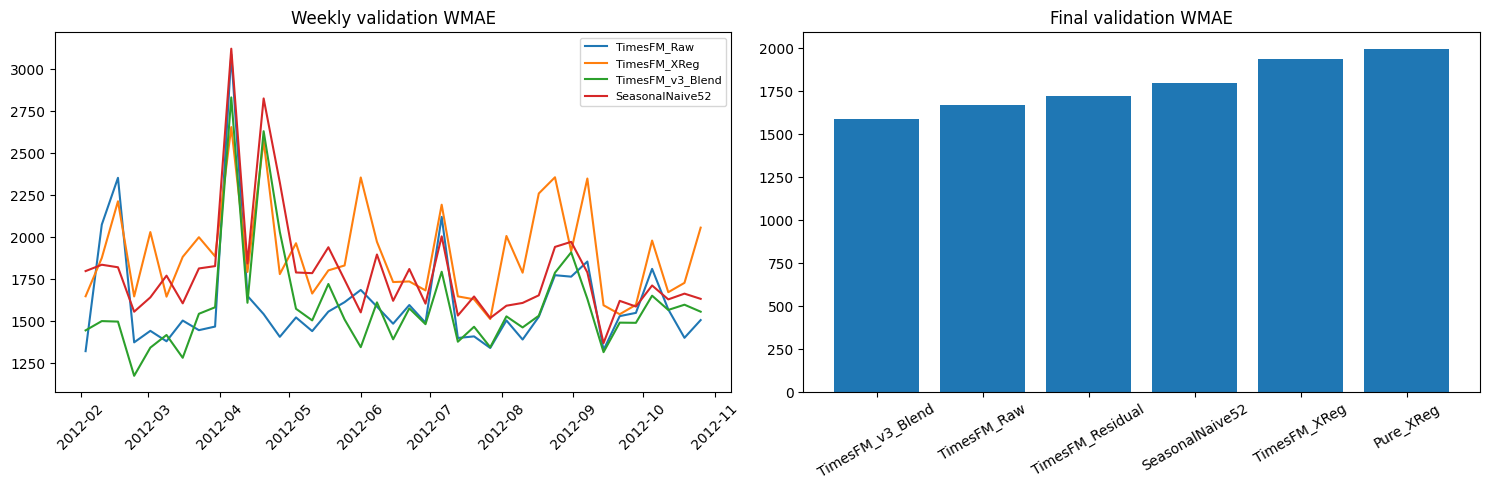

In [20]:
weekly = (
    validation_df.groupby("Date")
    .apply(
        lambda g: pd.Series(
            {
                n: wmae(g.Weekly_Sales, g[n], g.IsHoliday, CONFIG["holiday_weight"])
                for n in [
                    "TimesFM_Raw",
                    "TimesFM_XReg",
                    "TimesFM_v3_Blend",
                    "SeasonalNaive52",
                ]
            }
        ),
        include_groups=False,
    )
    .reset_index()
)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for n in ["TimesFM_Raw", "TimesFM_XReg", "TimesFM_v3_Blend", "SeasonalNaive52"]:
    axes[0].plot(weekly.Date, weekly[n], label=n)
axes[0].set_title("Weekly validation WMAE")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(fontsize=8)
axes[1].bar(score_table.candidate, score_table.validation_wmae)
axes[1].set_title("Final validation WMAE")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plot_path = OUTPUT_DIR / "timesfm_v3_diagnostics.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()

## w&b logging

In [21]:
paths = {
    "calibration": OUTPUT_DIR / "calibration_predictions.csv",
    "validation": OUTPUT_DIR / "validation_predictions.csv",
    "weights": OUTPUT_DIR / "weight_search.csv",
    "scores": OUTPUT_DIR / "candidate_scores.csv",
    "modes": OUTPUT_DIR / "xreg_modes.csv",
    "metrics": OUTPUT_DIR / "metrics.json",
}
calibration_df.to_csv(paths["calibration"], index=False)
validation_df.to_csv(paths["validation"], index=False)
weight_search.to_csv(paths["weights"], index=False)
score_table.to_csv(paths["scores"], index=False)
mode_table.to_csv(paths["modes"], index=False)
manifest = {
    "experiment": "TimesFM v3 XReg and corrected calibrated blend",
    "model_id": CONFIG["model_id"],
    "fine_tuned": False,
    "source_v2_artifact": artifact.name,
    "prediction_sha256": prediction_hash,
    **metrics,
}
paths["metrics"].write_text(json.dumps(manifest, indent=2))
run = wandb.init(
    entity=CONFIG["wandb_entity"],
    project=CONFIG["wandb_project"],
    group="timesfm-experiments",
    job_type="xreg_zero_shot_validation",
    name=CONFIG["wandb_run_name"],
    config=CONFIG,
)
numeric_metrics = {
    k: v
    for k, v in metrics.items()
    if isinstance(v, (int, float, np.integer, np.floating))
}
run.log(numeric_metrics)
run.log(
    {
        "results/candidate_scores": wandb.Table(dataframe=score_table),
        "calibration/xreg_modes": wandb.Table(dataframe=mode_table),
        "calibration/top_weights": wandb.Table(dataframe=weight_search.head(100)),
        "validation/predictions": wandb.Table(dataframe=validation_df.head(20000)),
        "validation/diagnostics": wandb.Image(str(plot_path)),
    }
)
out_artifact = wandb.Artifact(
    "timesfm-v3-xreg-corrected-calibration", type="evaluation", metadata=manifest
)
for p in [*paths.values(), plot_path]:
    out_artifact.add_file(str(p))
run.log_artifact(out_artifact, aliases=["v3", "latest"])
run.summary.update(manifest)
run.finish()
print(
    {"wandb_logged": True, "artifact": out_artifact.name, "output_dir": str(OUTPUT_DIR)}
)

calibration/best_wmae,▁
calibration/w_SeasonalNaive52,▁
calibration/w_TimesFM_Raw,▁
calibration/w_TimesFM_Residual,▁
calibration/w_TimesFM_XReg,▁
coverage/series,▁
runtime/model_load_seconds,▁
runtime/xreg_minutes,▁
validation/improvement_vs_v2_pct,▁
validation/v2_reported_wmae,▁
+2,...


{'wandb_logged': True, 'artifact': 'timesfm-v3-xreg-corrected-calibration', 'output_dir': '/content/artifacts/timesfm_xreg_v3'}


## reading v3

compare `timesfm_xreg` against `timesfm_raw`, then compare `timesfm_v3_blend` against v2's `1620.54`. the calibration assertion guarantees that weight selection and final post-processing now use identical clipping. this remains zero-shot with respect to timesfm weights; xreg fits only its lightweight regression correction from each allowed context.